# 03. TPE Force Vector Solver

**Pipeline step 3 of 3** — uses a ResNet regression model to make initial force/angle guesses at each contact, then refines them by minimising the difference between the synthetic photoelastic image and the experimental image subject to force/torque equilibrium constraints.

## Inputs
- Trajectory `.pkl` from Step 1
- Contact bond `.pkl` from Step 2
- Pre-trained ResNet18 weights (`models/Contact_Force_ResNet_*.pth`)
- Photoelastic images (`Ib_*.png`)

## Outputs
- `PREDICTION_<EXP_NAME>.pkl` — ResNet initial guesses (force, angle) per contact
- `FORCE_FITTED_TEMP_<EXP_NAME>.csv` — fitted (force, alpha) per contact, appended frame-by-frame
- `<EXP_NAME>_Force_ResNet.pkl` — final corrected and symmetric force dataset

## Workflow
1. Crop contact ROIs and run ResNet → initial (force, angle) guesses
2. For each particle: optimise (force, alpha) to match the photoelastic image
3. Validate reciprocity (ij vs ji), symmetrise using the better-fitting side
4. Save

### Imports

In [1]:
import numpy as np
import cv2
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

### Utility functions — image processing

In [2]:
def iter_contact_roi_batches(F_bond, IMG_DIR, frame_lag=0, batch_size=256, progress_every=1):
    """
    Yield contact ROI images/metadata in small batches to avoid keeping all crops in memory.

    Yields:
        batch_images   – list of float32 cropped contact images
        batch_metadata – list of dicts with idx, frame, beta, xi, yi, ri
        total_seen     – cumulative number of contacts prepared so far
    """
    from IPython.display import clear_output

    F_bond = append_ij_angle_to_pdata(F_bond)
    grouped = F_bond.groupby('frame')

    batch_images = []
    batch_metadata = []
    total_seen = 0

    max_frame = int(F_bond.frame.max()) if len(F_bond) else 0
    for frame in range(1, max_frame + 1):
        if frame % progress_every == 0:
            clear_output(wait=True)
            print(f"Cropping contact ROIs — frame: {frame}/{max_frame}")

        if frame not in grouped.groups:
            continue

        img_path = os.path.join(IMG_DIR, f'Ib_{frame + frame_lag}.png')
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: could not read image {img_path}; skipping frame {frame}")
            continue

        frame_data = grouped.get_group(frame)
        for idx, pdata in frame_data.iterrows():
            try:
                img_crop = get_disk_img(pdata, img)
            except ValueError as e:
                print(f"Skipping contact {idx}: {e}")
                continue

            img_masked = crop_circle_with_mask_float(img_crop)
            r = int(pdata['ri'])
            center = (img_crop.shape[1] // 2, img_crop.shape[0] // 2)
            img_rotated = rotate_image(img_masked, pdata['beta'] * 180 / np.pi + 90)
            img_final = crop_top_center_square(img_rotated, center, r)

            batch_images.append(img_final)
            batch_metadata.append({
                'idx': idx,
                'frame': frame,
                'beta': pdata['beta'],
                'xi': pdata['xi'],
                'yi': pdata['yi'],
                'ri': pdata['ri']
            })
            total_seen += 1

            if len(batch_images) >= batch_size:
                yield batch_images, batch_metadata, total_seen
                batch_images, batch_metadata = [], []

        del img

    if batch_images:
        yield batch_images, batch_metadata, total_seen

    clear_output(wait=True)


def preprocess(image, radius):
    """Convert BGR crop to normalised grayscale, resized to match training input size."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    target = (80, 80) if radius == 37 else (100, 100)
    gray   = cv2.resize(image, target, interpolation=cv2.INTER_AREA)
    blurred = cv2.GaussianBlur(gray, (3, 3), 1).astype(np.float32)
    return blurred / blurred.max()


def crop_circle_with_mask_float(img):
    """Zero out pixels outside the inscribed circle of a square float image."""
    h, w = img.shape
    cy, cx = h // 2, w // 2
    radius = min(cx, cy)
    Y, X  = np.ogrid[:h, :w]
    mask  = (X - cx)**2 + (Y - cy)**2 <= radius**2
    return img * mask


def circular_roi_mask_from_pdata(pdata, idx, d, img_shape, roi_radius=None):
    """
    Boolean mask for a circular ROI centred along the i→j direction at distance d from i.
    roi_radius defaults to ri / 3.
    """
    xi, yi = pdata.iloc[idx]['xi'], pdata.iloc[idx]['yi']
    xj, yj = pdata.iloc[idx]['xj'], pdata.iloc[idx]['yj']
    if roi_radius is None:
        roi_radius = pdata.iloc[idx]['ri'] / 3
    dx, dy = xj - xi, yj - yi
    norm = np.hypot(dx, dy)
    if norm == 0:
        raise ValueError("Particles i and j are at the same position.")
    ux, uy = dx / norm, dy / norm
    cx = img_shape[1] / 2 + d * ux
    cy = img_shape[0] / 2 + d * uy
    Y, X = np.ogrid[:img_shape[0], :img_shape[1]]
    return (X - cx)**2 + (Y - cy)**2 <= roi_radius**2


def rotate_image(image, angle_degrees):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle_degrees, 1.0)
    return cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=0)


def crop_top_center_square(image, center, radius):
    h, w = image.shape[:2]
    side = int(radius)
    x1 = max(center[0] - side // 2, 0)
    x2 = min(center[0] + side // 2, w)
    return image[0:min(side, h), x1:x2]


def append_ij_angle_to_pdata(pdata):
    """Add a 'beta' column — the angle of the i→j vector."""
    pdata = pdata.copy()
    dx = pdata['xj'].to_numpy() - pdata['xi'].to_numpy()
    dy = pdata['yj'].to_numpy() - pdata['yi'].to_numpy()
    pdata['beta'] = np.arctan2(dy, dx)
    return pdata


def get_disk_img(pdata, img):
    """Crop, preprocess, and circle-mask the disk image for particle i."""
    img   = img[250:1200, :]
    entry = pdata.copy()
    if isinstance(entry, pd.DataFrame) and len(entry) > 1:
        entry = entry.iloc[0]

    x, y, r = int(np.around(entry['xi'])), int(np.around(entry['yi'])), int(entry['ri'])
    h, w    = img.shape[:2]
    y1, y2  = max(0, y - r), min(h, y + r)
    x1, x2  = max(0, x - r), min(w, x + r)
    img_crop = img[y1:y2, x1:x2]

    if img_crop.shape[0] == 0 or img_crop.shape[1] == 0:
        raise ValueError("Cropped region is empty — check particle position or radius.")

    return crop_circle_with_mask_float(preprocess(img_crop, r))


def get_contact_rois(F_bond, IMG_DIR, frame_lag=0):
    """
    Crop, orient, and collect one contact ROI image per row in F_bond.

    Returns:
        all_images   – list of float32 cropped contact images
        all_metadata – list of dicts with idx, frame, beta, xi, yi, ri
    """
    F_bond     = append_ij_angle_to_pdata(F_bond)
    all_images = []
    all_metadata = []

    # Pre-group to avoid O(N) scan per frame
    grouped = F_bond.groupby('frame')

    for frame in range(1, max(F_bond.frame) + 1):
        sys.stdout.write(f"\rCropping contact ROIs — frame: {frame}")
        sys.stdout.flush()

        if frame not in grouped.groups:
            continue

        frame_data = grouped.get_group(frame)
        img        = cv2.imread(os.path.join(IMG_DIR, f'Ib_{frame + frame_lag}.png'))

        for idx, pdata in frame_data.iterrows():
            try:
                img_crop = get_disk_img(pdata, img)
            except ValueError as e:
                print(f"\nSkipping contact {idx}: {e}")
                continue

            img_masked  = crop_circle_with_mask_float(img_crop)
            r           = int(pdata['ri'])
            center      = (img_crop.shape[1] // 2, img_crop.shape[0] // 2)
            img_rotated = rotate_image(img_masked, pdata['beta'] * 180 / np.pi + 90)
            img_final   = crop_top_center_square(img_rotated, center, r)

            all_images.append(img_final)
            all_metadata.append({
                'idx': idx, 'frame': frame,
                'beta': pdata['beta'],
                'xi': pdata['xi'], 'yi': pdata['yi'], 'ri': pdata['ri']
            })

    print(f"\nTotal contacts processed: {len(all_images)}")
    return all_images, all_metadata


### Model architecture & physics solver

In [4]:
def get_model(device, output_dim=2):
    """
    Build a ResNet18-based regression model for contact force and angle prediction.

    Parameters
    ----------
    device     : torch.device
    output_dim : int   number of output values (default 2 → [force, angle])
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, output_dim)
    )
    return model.to(device)


# Global coordinate mesh cache — avoids recomputing on every call
_mesh_cache = {}

def StressSolve_residue_torch(xxi, xxj, f, alpha, beta, fsigma, rm, power, eps=1e-10):
    """
    Vectorised photoelastic intensity for a disk with z contacts.

    xxi, xxj : [HW] pixel coordinate tensors (inside unit disk)
    f, alpha, beta : [z] contact force magnitude, opening angle, contact angle
    Returns [HW] intensity tensor.
    """
    device = xxi.device
    beta_adj = -beta + torch.pi / 2

    pioverfsigma = torch.pi / fsigma
    twooverpi    = 2 / torch.pi

    xxi_exp   = xxi.unsqueeze(0)
    xxj_exp   = xxj.unsqueeze(0)
    f_exp     = f.unsqueeze(1)
    alpha_exp = alpha.unsqueeze(1)
    beta_exp  = beta_adj.unsqueeze(1)

    b  = beta_exp + torch.pi / 2
    a  = alpha_exp
    b2 = torch.where(a < 0, b + (torch.pi + 2 * a), b - (torch.pi - 2 * a))

    x1 = rm * torch.sin(b);  y1 = rm * torch.cos(b)
    x2 = rm * torch.sin(b2); y2 = rm * torch.cos(b2)

    ch0 = x2 - x1;  ch1 = y2 - y1
    chn = torch.sqrt(ch0**2 + ch1**2 + eps)
    ch0 = ch0 / chn;  ch1 = ch1 / chn

    r10 = xxi_exp - x1
    r11 = -xxj_exp - y1
    r1n = torch.sqrt(r10**2 + r11**2 + eps)

    costh1 = torch.clamp((r10 * ch0 + r11 * ch1) / r1n, -1 + eps, 1 - eps)
    signth = torch.where(r11 * ch0 > r10 * ch1, 1.0, -1.0)
    th1    = signth * torch.acos(costh1)

    s1 = -(f_exp * twooverpi) / r1n * costh1
    th = th1 - beta_exp - alpha_exp

    sigmaxx = torch.sum(s1 * torch.sin(th)**2,          dim=0)
    sigmayy = torch.sum(s1 * torch.cos(th)**2,          dim=0)
    sigmaxy = torch.sum(0.5 * s1 * torch.sin(2 * th),   dim=0)

    # Residual stress
    R       = torch.sqrt(xxi**2 + xxj**2 + eps)
    K_res   = -fsigma / (torch.pi * power * rm**power) * torch.arcsin(torch.tensor(1., device=device)**0.5)
    s_r_res = K_res * (rm**power - R**power)
    s_t_res = K_res * (rm**power - (power + 1) * R**power)
    Theta   = torch.atan2(xxi, xxj)

    cos2, sin2 = torch.cos(Theta)**2, torch.sin(Theta)**2
    sincos     = torch.sin(Theta) * torch.cos(Theta)

    sigmaxx_tot = sigmaxx + s_r_res * cos2 + s_t_res * sin2
    sigmayy_tot = sigmayy + s_r_res * sin2 + s_t_res * cos2
    sigmaxy_tot = sigmaxy + (s_r_res - s_t_res) * sincos

    aa     = torch.sqrt((sigmaxx_tot - sigmayy_tot)**2 + 4 * sigmaxy_tot**2)
    result = torch.sin(pioverfsigma * aa)**2
    return torch.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)


def synth_img_pytorch_residue(fsigma, rm, px, f, alpha, beta, device='cuda'):
    """Generate a synthetic photoelastic disk image on a px×px grid."""
    cache_key = (px, rm, device)
    if cache_key not in _mesh_cache:
        x = torch.linspace(-rm, rm, px, device=device)
        xxi, xxj = torch.meshgrid(x, x, indexing='ij')
        xxi_flat, xxj_flat = xxi.reshape(-1), xxj.reshape(-1)
        mask = xxi_flat**2 + xxj_flat**2 <= rm**2
        _mesh_cache[cache_key] = {
            'xxi_flat': xxi_flat, 'xxj_flat': xxj_flat,
            'mask': mask,
            'template': torch.zeros(px * px, device=device)
        }
    c = _mesh_cache[cache_key]
    intensity = StressSolve_residue_torch(
        c['xxi_flat'][c['mask']], c['xxj_flat'][c['mask']],
        f, alpha, beta, fsigma, rm, power=10
    )
    img = c['template'].clone()
    img[c['mask']] = intensity
    return img.reshape(px, px)


def gaussian_kernel(kernel_size=3, sigma=1.0, device='cuda'):
    x = torch.arange(kernel_size, dtype=torch.float32, device=device) - (kernel_size - 1) / 2
    g = torch.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()
    return (g[:, None] @ g[None, :])


def smooth_image(img, kernel_size=3, sigma=1.0):
    """Apply a 2-D Gaussian blur to a single-channel [H,W] tensor."""
    device = img.device
    k = gaussian_kernel(kernel_size, sigma, device).unsqueeze(0).unsqueeze(0)
    return F.conv2d(img.unsqueeze(0).unsqueeze(0), k,
                    padding=kernel_size // 2).squeeze(0).squeeze(0)


def fit_disk_residue(photo_img, fsigma, rm, px, f0, alpha0, beta,
                     lr, n_iter=1000, device='cuda', verbose=0,
                     tol=5e-4, patience=300):
    """
    Optimise (f0, alpha0) to minimise image reconstruction + equilibrium losses.

    Returns: f_fit, alpha_fit, final_loss, loss_history
    """
    f0     = f0.clone().detach().to(device).requires_grad_(True)
    alpha0 = alpha0.clone().detach().to(device).requires_grad_(True)
    beta   = beta.to(device)

    optimizer       = torch.optim.Adam([f0, alpha0], lr=lr)
    pi_half         = torch.tensor(torch.pi / 2, device=device)
    torque_weight   = torch.tensor(1e5, device=device)

    prev_loss        = None
    patience_counter = 0
    loss_history     = []

    for i in range(n_iter):
        optimizer.zero_grad()

        f0_pos = torch.abs(f0)
        synth  = synth_img_pytorch_residue(fsigma, rm, px, f0_pos, alpha0, beta)

        image_loss  = ((smooth_image(synth) - photo_img) ** 2).mean()
        angle_term  = alpha0 - beta + pi_half
        torque_loss = torque_weight * torch.sum(torch.sin(alpha0) * rm * f0_pos) ** 2
        force_loss  = torch.sum(torch.cos(angle_term) * f0_pos) ** 2 + \
                      torch.sum(torch.sin(angle_term) * f0_pos) ** 2
        loss        = image_loss + torque_loss + force_loss

        if verbose and i % 10 == 0:
            print(f"Iter {i}: loss={loss.item():.4f}  image={image_loss.item():.4f}  "
                  f"torque={torque_loss.item():.4f}  force={force_loss.item():.4f}")

        if torch.isnan(loss) or torch.isinf(loss):
            print("Loss diverged — stopping.")
            break

        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        loss_history.append(current_loss)

        if prev_loss is not None:
            patience_counter = patience_counter + 1 if prev_loss - current_loss < tol else 0
            if patience_counter >= patience:
                break
        prev_loss = current_loss

    return f0.detach().cpu().numpy(), alpha0.detach().cpu().numpy(), loss.detach(), loss_history

### Parameters — edit here before running

In [5]:
EXP_NAME  = 'TPE_20260302A01_N=267x2_5e-4rps_5fps_steady_2000frames_denoise'

IMG_DIR  = os.path.join(r'N:\PROJ_TPE', EXP_NAME)
TRAJ_DIR = r'M:\Archive\Proj_TPE\Disk_traj_files'
BOND_DIR = r'M:\Archive\Proj_TPE\Contact_bond_files'
OUT_DIR  = r'M:\Archive\Proj_TPE\Force Inversion'

frame_lag = 1  # image index offset between trajectory frames and PE images

# Derived paths
traj_filename = os.path.join(TRAJ_DIR, f'{EXP_NAME}.pkl')
bond_filename = os.path.join(BOND_DIR,  f'CONTACT_BOND_{EXP_NAME}.pkl')

F_bond = pd.read_pickle(bond_filename)
F_traj = pd.read_pickle(traj_filename)

# Load force prediction model
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = os.path.join(os.getcwd(), 'models', 'Contact_Force_ResNet_20260130.pth')
model      = get_model(DEVICE)
model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()

print(f"Model loaded: {model_path}")
print(f"Running on:   {DEVICE}")

Model loaded: o:\LJJ202107\LJJ Jupyter Notebook Collection\TPE_image_process_pipeline\models\Contact_Force_ResNet_20260130.pth
Running on:   cuda


### Make initial guess for forces and angles

First crop and append all ROIs, append to list.
Then make initial guess in batches, append back to F_bond (~ 30 min)

In [12]:
# Define transforms (same as training)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

ROI_BATCH_SIZE = 256      # CPU-side ROI accumulation batch
INFER_BATCH_SIZE = 32     # GPU/CPU inference mini-batch

model.eval()

############### Initialize output frame ###############
F_bond_pred = F_bond.copy()
F_bond_pred['force_pred'] = np.nan
F_bond_pred['angle_pred'] = np.nan

print(f"Starting streaming ROI extraction (roi_batch={ROI_BATCH_SIZE})", flush=True)
print(f"Inference mini-batch={INFER_BATCH_SIZE} on device={DEVICE}", flush=True)


def to_pil_uint8(img):
    img = np.asarray(img)
    if img.max() <= 1.0:
        img8 = (img * 255).clip(0, 255).astype(np.uint8)
    else:
        img8 = img.clip(0, 255).astype(np.uint8)
    return Image.fromarray(img8)


############################# STREAMED MODEL PREDICTION ###############################
processed_contacts = 0
chunk_id = 0

with torch.no_grad():
    for chunk_images, chunk_meta, total_seen in iter_contact_roi_batches(
        F_bond, IMG_DIR, frame_lag=frame_lag, batch_size=ROI_BATCH_SIZE
    ):
        chunk_id += 1

        for start in range(0, len(chunk_images), INFER_BATCH_SIZE):
            end = min(start + INFER_BATCH_SIZE, len(chunk_images))
            batch_imgs = [data_transform(to_pil_uint8(im)) for im in chunk_images[start:end]]
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            batch_predictions = model(batch_tensor).cpu().numpy()

            idxs = [m['idx'] for m in chunk_meta[start:end]]
            F_bond_pred.loc[idxs, 'force_pred'] = batch_predictions[:, 0]
            F_bond_pred.loc[idxs, 'angle_pred'] = batch_predictions[:, 1]

            processed_contacts += len(idxs)

            del batch_tensor, batch_imgs, batch_predictions
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        del chunk_images, chunk_meta





Cropping contact ROIs — frame: 2000/2000


In [14]:
# Write F_bond_pred to pickle
output_path = os.path.join(OUT_DIR, f'PREDICTION_{EXP_NAME}.pkl')
F_bond_pred.to_pickle(output_path)

### Starts fitting 

In [6]:
fsigma = 225
plot_every = 0 # Once this open(plot_every = 1), plot figure of balls
verbose = 0

# Define output CSV path
output_csv_path = os.path.join(OUT_DIR, f'FORCE_FITTED_TEMP_{EXP_NAME}.csv')

F_bond_pred = pd.read_pickle(os.path.join(OUT_DIR, f'PREDICTION_{EXP_NAME}.pkl'))
F_bond_pred = append_ij_angle_to_pdata(F_bond_pred)

# Determine whether we should resume from existing CSV
all_frames = sorted(F_bond_pred['frame'].unique())
frames_to_process = all_frames

if os.path.exists(output_csv_path):
    try:
        existing = pd.read_csv(output_csv_path, usecols=['frame'])
        existing = existing.dropna(subset=['frame'])

        if len(existing) > 0:
            last_processed_frame = int(existing['frame'].max())
            frames_to_process = [f for f in all_frames if f > last_processed_frame]
            print(f"Resuming from existing CSV. Last processed frame: {last_processed_frame}")
            print(f"Frames remaining: {len(frames_to_process)}")
        else:
            print("Existing CSV is empty. Starting from first frame.")
    except Exception as e:
        print(f"Could not read existing CSV ({e}). Starting from first frame.")

if len(frames_to_process) == 0:
    print(f"No new frames to process. Existing results are up to date: {output_csv_path}")

for frame in frames_to_process:
#for frame in np.arange(2,3):  # For testing specific frames   
    print(f"\rProcessing frame: {frame}", end='', flush=True) 
    
    # Initialize list for this frame's results
    frame_data_out = []
    
    image_path = os.path.join(IMG_DIR, 'Ib_'+str(frame+frame_lag)+'.png')
    img = cv2.imread(image_path)

    frame_force = F_traj[F_traj.frame==frame]
    frame_data = F_bond_pred[F_bond_pred['frame'] == frame]
    
    for particle_id, pdata in frame_data.groupby('i'):
        z = len(pdata) #CONTACT NUMBER 
        pdata = pdata.reset_index(drop=True)
        
        ########################## If i is singular, skip ############################
        if z == 1:
            continue
        ######################### Begin inversion if z>1 ############################
        else:
             #give beta column to pdata
            GrayImg = get_disk_img(pdata, img) 
            
            # Ensure grayscale (convert BGR to grayscale if needed)
            if len(GrayImg.shape) == 3:
                GrayImg = cv2.cvtColor(GrayImg, cv2.COLOR_BGR2GRAY)
            
            # Normalize to [0, 1]
            GrayImg = GrayImg.astype(np.float32) / 255.0 if GrayImg.max() > 1 else GrayImg.astype(np.float32)
            
            pdata_out = pdata.copy()        
            rm = pdata.iloc[0]['ri']/37*6/1000 # rm is radius meter, value of radius
            img_size = GrayImg.shape[0]
        
            ############################ Initial force guesses ################################
            alphas = pdata['angle_pred'].to_numpy().copy()   #call beta from bond file data
            betas = pdata['beta'].to_numpy().copy()   #call beta from bond file data
            forces = pdata['force_pred'].to_numpy().copy()   #call beta from bond file data

            #alphas, forces = forceBalance(forces.copy(), alphas.copy(), betas) # Apply force balance

            if verbose:
                print(f"Particle id: {particle_id}, Contact number z={z}")
                print(f"Initial forces: {forces}")
                print(f"Initial alphas: {alphas}")

            ############################# Set initial guesses to pytorch #######################################

            f0_gpu = torch.tensor(forces.tolist(), dtype=torch.float32, device='cuda')  # Force magnitude
            alpha0_gpu = torch.tensor(alphas.tolist(), dtype=torch.float32, device='cuda')  # Force angles
            betas_gpu = torch.tensor(betas.tolist(), dtype=torch.float32, device='cuda')  # Force angles
            GrayImg = torch.tensor(GrayImg, dtype=torch.float32, device='cuda')

            guess_im = synth_img_pytorch_residue(fsigma, rm, img_size, f0_gpu, alpha0_gpu, betas_gpu, device='cuda')
            
            ############################ Start fitting #########################################            
            res = fit_disk_residue(GrayImg, fsigma, rm, img_size, f0_gpu, alpha0_gpu, betas_gpu, 
                                   verbose=verbose,tol=1e-3, patience=10, lr=4e-2, n_iter=1000)
            f_fit, alpha_fit, fitted_loss, loss_hist = res
            
            ####################### Plot results if desired ###########################
            if verbose:
                print('Fitted Loss:', fitted_loss.cpu().numpy())
                print(f"Fitted forces: {f_fit}")
                print(f"Fitted alphas: {alpha_fit}")

            if plot_every and fitted_loss.cpu().numpy()> 0:
                fit_im = synth_img_pytorch_residue(
                    fsigma, rm, img_size,
                    torch.tensor(f_fit, dtype=torch.float32, device='cuda'),
                    torch.tensor(alpha_fit, dtype=torch.float32, device='cuda'),
                    betas_gpu, device='cuda'
                )

                plt.figure(figsize = (6,2))
                plt.subplot(1, 3, 1)
                plt.imshow(GrayImg.cpu().numpy(), cmap='gray', vmax = 1)
                plt.title(f"id = {particle_id} \n exp", fontsize=10)
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(smooth_image(guess_im, kernel_size=3, sigma=1.0).cpu().numpy(), cmap='gray', vmax=1)
                plt.title("guess", fontsize=10)
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(smooth_image(fit_im, kernel_size=3, sigma=1.0).cpu().numpy(), cmap='gray', vmax=1)
                plt.title("fit", fontsize=10)
                plt.axis('off')
                plt.show()
            #################### Append particle results to frame data #############

            pdata_out['force'] = f_fit
            pdata_out['alpha'] = alpha_fit
            pdata_out['fitLoss'] = fitted_loss.cpu().numpy()

        frame_data_out.append(pdata_out)
    
    # Append this frame's results to CSV file (efficient append without reading entire file)
    if frame_data_out:
        frame_results = pd.concat(frame_data_out, ignore_index=True)
        
        # Write header only if file does not exist or is empty
        write_header = (not os.path.exists(output_csv_path)) or os.path.getsize(output_csv_path) == 0
        frame_results.to_csv(output_csv_path, mode='a', header=write_header, index=False)

print(f"\nProcessing complete! Results saved to: {output_csv_path}")



Resuming from existing CSV. Last processed frame: 1402
Frames remaining: 598
Processing frame: 2000
Processing complete! Results saved to: M:\Archive\Proj_TPE\Force Inversion\FORCE_FITTED_TEMP_TPE_20260302A01_N=267x2_5e-4rps_5fps_steady_2000frames_denoise.csv


### Calculate ij/ji force difference for validation

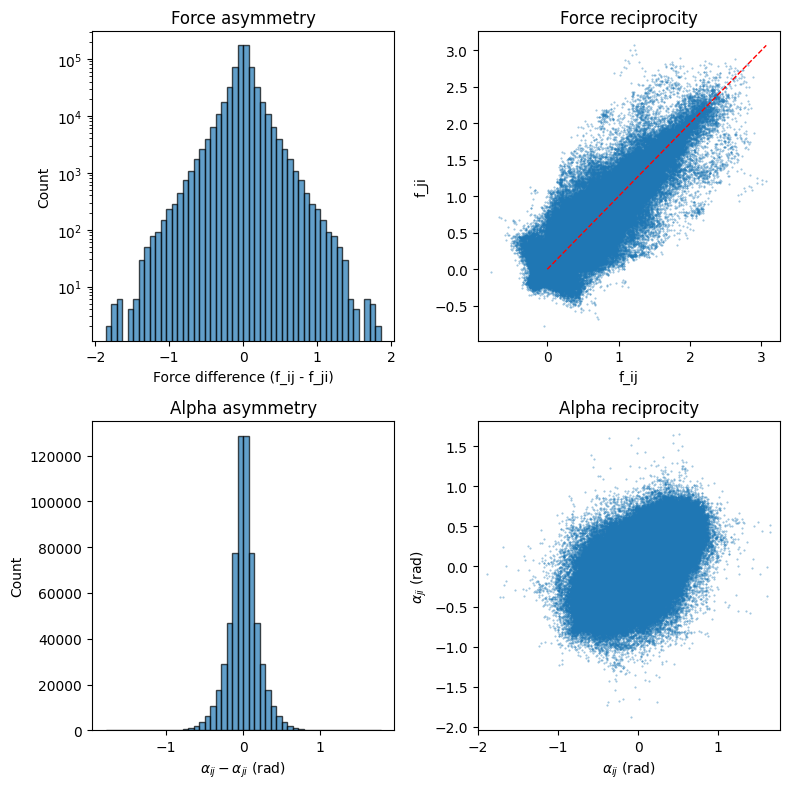

In [14]:
# Load the fitted results from CSV
F_bond_out = pd.read_csv(os.path.join(OUT_DIR, f'FORCE_FITTED_TEMP_{EXP_NAME}.csv'))
F_bond_out.drop_duplicates(subset=['frame', 'i', 'j'], keep='first', inplace=True)

# Create a copy with swapped i and j to find reciprocal contacts
F_swap = F_bond_out[['frame', 'i', 'j', 'force', 'alpha', 'fitLoss']].copy()
F_swap.columns = ['frame', 'j', 'i', 'force_ji', 'alpha_ji', 'fitLoss_ji']

# Merge to get both ij and ji forces in one row
F_compare = F_bond_out.merge(F_swap, on=['frame', 'i', 'j'], how='inner')

# Compute force differences
F_compare['force_diff'] = F_compare['force'] - F_compare['force_ji']
F_compare['force_diff_normalized'] = F_compare['force_diff'] / (F_compare['force_ji'] + 1e-10)

# Compute alpha differences (accounting for periodicity)
F_compare['alpha_diff'] = abs(F_compare['alpha']) - abs(F_compare['alpha_ji'])
# Normalize angular difference to [-pi, pi]
F_compare['alpha_diff_norm'] = np.arctan2(
    np.sin(F_compare['alpha_diff']), 
    np.cos(F_compare['alpha_diff'])
)

# Check if alphas are opposite (should differ by ~π for action-reaction pairs)
F_compare['alpha_opposite'] = np.abs(np.abs(F_compare['alpha_diff_norm']) - np.pi) < 0.1

# Plot histograms and scatter plots
fig = plt.figure(figsize=(8, 8))

# Force difference histogram
plt.subplot(2, 2, 1)
plt.hist(F_compare['force_diff'], bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Force difference (f_ij - f_ji)')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Force asymmetry')

# Force reciprocity scatter
plt.subplot(2, 2, 2)
plt.scatter(F_compare['force'], F_compare['force_ji'], s=0.2, alpha=0.5)
plt.plot([0, F_compare['force'].max()], [0, F_compare['force'].max()], 'r--', lw=1)
plt.xlabel('f_ij')
plt.ylabel('f_ji')
plt.title('Force reciprocity')


# Alpha difference histogram
plt.subplot(2, 2, 3)
plt.hist(F_compare['alpha_diff_norm'], bins=50, edgecolor='k', alpha=0.7)
plt.xlabel(r'$\alpha_{ij} - \alpha_{ji}$ (rad)')
plt.ylabel('Count')
plt.title('Alpha asymmetry')

# Alpha reciprocity scatter
plt.subplot(2, 2, 4)
plt.scatter(F_compare['alpha'], F_compare['alpha_ji'], s=0.2, alpha=0.5)
plt.xlabel(r'$\alpha_{ij}$ (rad)')
plt.ylabel(r'$\alpha_{ji}$ (rad)')
plt.title('Alpha reciprocity')
plt.axis('equal')

plt.tight_layout()
plt.show()


### Check all ij/ji pairs, make all f and alpha equal to the one with smaller fitLoss

In [23]:
# Make a copy and take absolute values of all forces
F_bond_corrected = F_bond_out.copy()
F_bond_corrected['force'] = np.abs(F_bond_corrected['force'])

# Create a mapping: for each contact, store the better (lower loss) values from its ij/ji pair
# Key: (frame, i, j), Value: (best_force, best_alpha)
best_values = {}

for _, row in F_compare.iterrows():
    frame = int(row['frame'])
    i = int(row['i'])
    j = int(row['j'])
    
    # Determine which side has lower loss
    if row['fitLoss'] <= row['fitLoss_ji']:
        # ij is better, use its values for both ij and ji
        best_force = np.abs(row['force'])
        best_alpha = row['alpha']
    else:
        # ji is better, use its values for both ij and ji
        best_force = np.abs(row['force_ji'])
        best_alpha = row['alpha_ji']
    
    # Store the best value for both ij and ji contacts
    best_values[(frame, i, j)] = (best_force, best_alpha)
    best_values[(frame, j, i)] = (best_force, best_alpha)

# Now vectorized update: only update contacts that are in reciprocal pairs
for idx, row in F_bond_corrected.iterrows():
    key = (int(row['frame']), int(row['i']), int(row['j']))
    if key in best_values:
        F_bond_corrected.loc[idx, 'force'] = best_values[key][0]
        F_bond_corrected.loc[idx, 'alpha'] = best_values[key][1]

print(f"Total contacts: {len(F_bond_corrected)}")
print(f"Contacts with reciprocal pairs corrected: {len(best_values)//2}")
print(f"Contacts without reciprocal pairs (unchanged): {len(F_bond_corrected) - len(best_values)//2}")

Total contacts: 726875
Contacts with reciprocal pairs corrected: 323471
Contacts without reciprocal pairs (unchanged): 403404


### Check results by drawing full-field synth img from fitted resuls

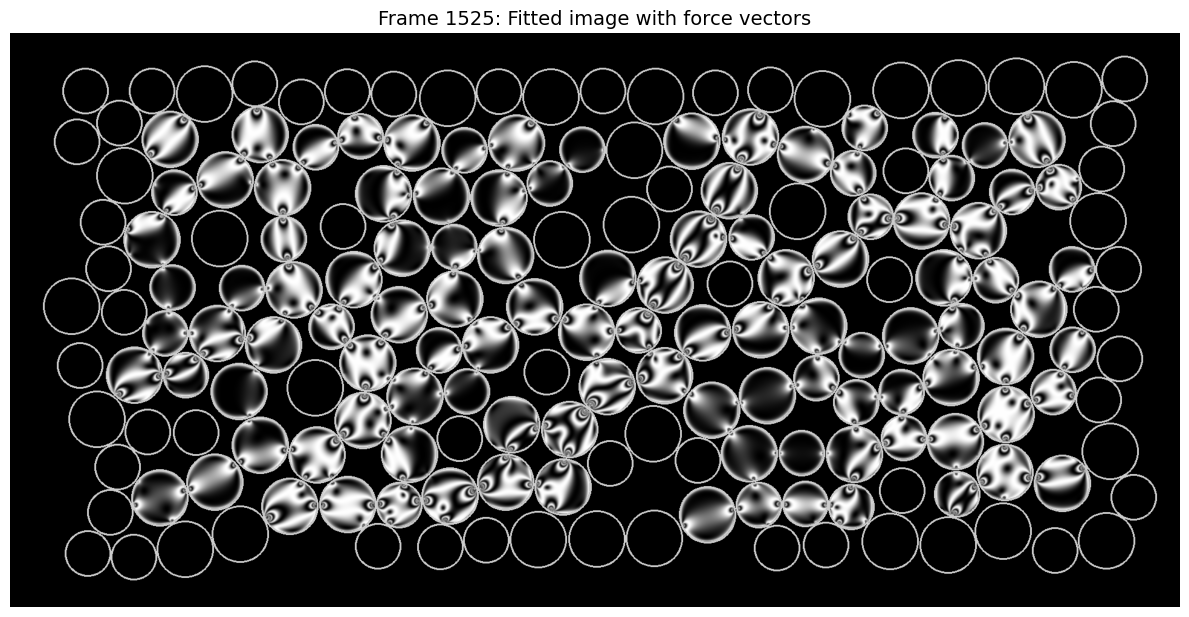

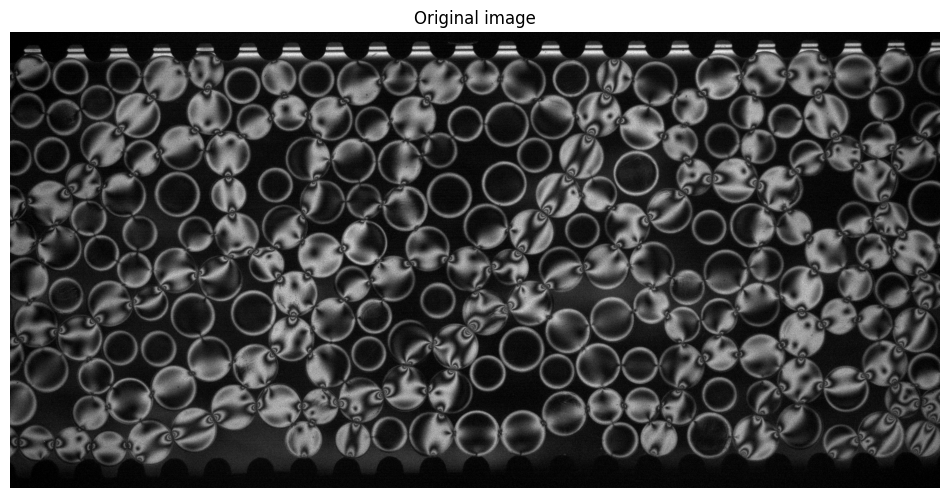

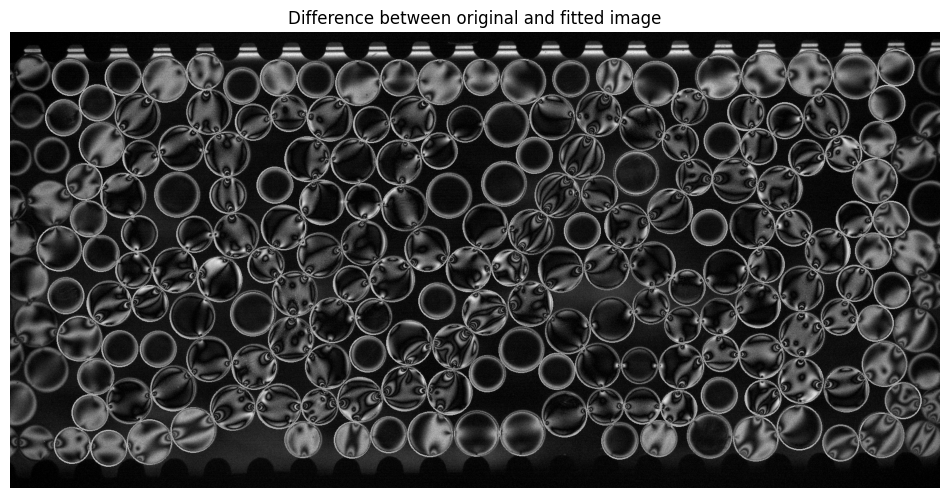

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fsigma = 225
frame = 1525
f = F_bond_corrected[F_bond_corrected.frame==frame].copy()

# Load the original PE image
image_path = os.path.join(IMG_DIR, 'Ib_'+str(frame+frame_lag)+'.png')
orig_img = cv2.imread(image_path)
orig_img = orig_img[250:1200, :]  # Apply the same crop as in get_img_and_force

output_img = np.zeros_like(orig_img, dtype=np.float32)
count_img = np.zeros_like(orig_img, dtype=np.float32)

for particle_id, entry in f.groupby('i'):
    x = int(np.around(entry['xi'].iloc[0]))
    y = int(np.around(entry['yi'].iloc[0]))
    r = int(entry['ri'].iloc[0])
    h, w = orig_img.shape[:2]
    y1, y2 = max(0, y - r), min(h, y + r)
    x1, x2 = max(0, x - r), min(w, x + r)
    crop_h, crop_w = y2 - y1, x2 - x1

    # Only plot if fit results exist and are valid
    if 'force' in entry and 'alpha' in entry:
        z = len(entry['force'])
        if z > 1:
            rm = entry['ri'].iloc[0]/37*6/1000
            px = crop_h
            f0 = torch.tensor((entry['force']).tolist(), dtype=torch.float32, device='cuda')
            alpha0 = torch.tensor(entry['alpha'].tolist(), dtype=torch.float32, device='cuda')
            beta = torch.tensor(entry['beta'].tolist(), dtype=torch.float32, device='cuda')
            fit_im = synth_img_pytorch_residue(fsigma, rm, px, f0, alpha0, beta, device='cuda')
            im_smoothed = smooth_image(fit_im, kernel_size=3, sigma=1.0)
            fit_img_np = im_smoothed.cpu().numpy()
            fit_img_cropped = crop_circle_with_mask_float(fit_img_np)
            fit_img_resized = cv2.resize(fit_img_cropped, (crop_w, crop_h), interpolation=cv2.INTER_LINEAR)
            if len(orig_img.shape) == 3 and orig_img.shape[2] == 3:
                fit_img_resized = np.stack([fit_img_resized]*3, axis=-1)
            output_img[y1:y2, x1:x2] += fit_img_resized
            count_img[y1:y2, x1:x2] += (fit_img_resized > 0).astype(np.float32)

# Plot empty circles for disks without contacts
all_particle = F_traj[F_traj.frame==frame]

for _, row in all_particle.iterrows():
    cx = int(round(float(row.x)))
    cy = int(round(float(row.y)))
    center = (cx, cy)
    radius = int(round(float(row.rpx)))

    h_out, w_out = output_img.shape[:2]
    if radius <= 0 or cx < 0 or cy < 0 or cx >= w_out or cy >= h_out:
        continue

    color = 0.8
    thickness = 2

    if output_img.ndim == 3 and output_img.shape[2] == 3:
        cv2.circle(output_img, center, radius, (color, color, color), thickness)
    else:
        cv2.circle(output_img, center, radius, color, thickness)

count_img[count_img == 0] = 1
final_img = output_img

orig_img = orig_img/orig_img.max()
diff_img = cv2.absdiff((orig_img).astype(np.float32), final_img.astype(np.float32))

# Convert grayscale to RGB for overlaying colored arrows
orig_gray = cv2.cvtColor((orig_img*255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

# Plot 1: All fitted balls overlaid with force vectors
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(final_img.astype(np.float32), cmap='gray')

# Draw force vectors from contact points
arrow_scale = 50
if 0:
    for _, contact in f.iterrows():
        xi = float(contact['xi'])
        yi = float(contact['yi'])
        xj = float(contact['xj'])
        yj = float(contact['yj'])
        ri = float(contact['ri'])
        
        force_mag = float(contact['force'])
        alpha = float(contact['alpha'])
        beta = float(contact['beta'])
        
        # Calculate contact point
        dx = xj - xi
        dy = yj - yi
        dist_ij = np.sqrt(dx**2 + dy**2)
        
        if dist_ij > 0:
            ux = dx / dist_ij
            uy = dy / dist_ij
            
            contact_x = xi + ri * ux
            contact_y = yi + ri * uy
            
            theta = -beta + alpha
            fx = force_mag * np.cos(theta) * arrow_scale
            fy = -force_mag * np.sin(theta) * arrow_scale
            
            ax.arrow(contact_x, contact_y, fx, fy, 
                    head_width=5, head_length=8, 
                    fc='red', ec='red', 
                    linewidth=1.5, alpha=0.7)

ax.set_xlim(0, final_img.shape[1])
ax.set_ylim(final_img.shape[0], 0)
ax.axis('off')
ax.set_title(f'Frame {frame}: Fitted image with force vectors', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Original image
plt.figure(figsize=(12, 12))
plt.imshow((orig_img).astype(np.float32), cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()

# Plot 3: Difference between original and fitted
plt.figure(figsize=(12, 12))
plt.imshow(diff_img, cmap='gray')
plt.title('Difference between original and fitted image')
plt.axis('off')
plt.show()


### Save to disk

In [25]:
# Optional: Convert CSV to pickle for faster loading in future analyses
out_filename = os.path.join(OUT_DIR, EXP_NAME + '_Force_ResNet.pkl')
F_bond_corrected.to_pickle(out_filename)
print(f"Saved final corrected results to: {out_filename}")

Saved final corrected results to: M:\Archive\Proj_TPE\Force Inversion\TPE_20260302A01_N=267x2_5e-4rps_5fps_steady_2000frames_denoise_Force_ResNet.pkl
